# Clinical versus pathological staging

In [1]:
import os
import sys
from dataclasses import replace
sys.path[:0] = [os.path.abspath("scripts"), os.path.abspath(".."), os.path.abspath("../differential_rules")]
import complex_investigation as ci
import complex_investigation_vis as vis
from IPython.display import display

In [2]:
CONFIG = ci.Config(support=0.01, expected_support=0.01, confidence=0.5,
                   min_cells=20, min_fovs=5, min_patients=3,
                   min_group_fovs=10, permutations=4999, top_n=8)

The same automatically selected rules, same investigation filters and same FOV eligibility are shown under both scores. Each score gets its own FOV, biopsy and patient permutation tests and BH family. Patient tests average biopsies equally and omit patients spanning stages. These are alternative groupings of the same tissue, not independent replication.

In [3]:
cells, metadata, rules = ci.load(CONFIG)
clinical = ci.analyse(rules, cells, metadata, CONFIG)
pathological = ci.analyse(rules, cells, metadata, replace(CONFIG, score="Pathological score"))

Dropped 21 FOVs: Control_S


Loaded 598093 cells; FOVs: 267, biopsies: 73, patients: 71


Read results_CN_pairwise.csv + results_CN_complex.csv


{'max_items': 4, 'min_cells': 20, 'mining_fdr': 0.05, 'support': 0.01, 'confidence': 0.5, 'expected_support': 0.01, 'score': 'Clinical score', 'min_fovs': 5, 'min_patients': 3, 'min_group_fovs': 10, 'visible_gap': 0.15, 'attraction_lift_gap': 0.3, 'avoidance_lift_gap': 0.15, 'permutations': 4999, 'top_n': 8}
690,345 stored center-specific occurrences; distinct cell types only
Mining settings: {'settings': {'weighting': 'binary', 'method': 'CN', 'radius': 25.0, 'min_support': 0.01, 'min_lift': 1.2, 'max_items_per_rule': 4, 'bandwidth': 15.0, 'k_neighbors': None, 'min_cells_per_patch': 2, 'max_one_type_share': 0.9, 'min_patches': 15, 'strong_confidence': 0.9, 'min_support_when_strong': 0.005, 'min_confidence': 0.5, 'min_leverage': 0.0005, 'min_conviction': 1.3, 'include_avoidance_rules': True, 'avoidance_max_lift': 0.8, 'avoidance_max_leverage': None, 'avoidance_min_expected_meetings': 30, 'min_label_count': 5, 'min_label_share': None, 'decay_distance': 15.0}, 'steps': {'n_shuffles': 100

In [4]:
SPECS = ci.candidates(clinical['counts'], clinical['tests'], CONFIG)
SPECS = SPECS.groupby(['organ', 'kind'], sort=False).head(1).reset_index(drop=True)
ci.save_tables(clinical, SPECS, 'staging_clin')
ci.save_tables(pathological, SPECS, 'staging_path')
display(SPECS)

,organ,rule,kind,gap,contrast,patient_fdr,hits,patients,eligible,share,stream
0,Colon,Goblet -> CD8T + Fibroblast + Plasma,avoids,0.630000,Control–Severe,0.350240,18,5,47,0.382979,visible
1,Duodenum,Muscle -> Endothelial + Plasma_CD38,avoids,0.500000,Control–Severe,0.733877,14,10,56,0.250000,visible
2,Colon,Epithelial + Fibroblast -> Plasma,attracts,0.481538,Control–Severe,0.642713,14,5,55,0.254545,visible
3,Duodenum,Fibroblast + Paneth -> Epithelial + Neuron,attracts,0.447552,Control–Severe,0.674259,18,11,75,0.240000,visible


In [5]:
def show_selected(index):
    if index >= len(SPECS):
        return
    spec = SPECS.iloc[index].to_dict()
    vis.summary(clinical, metadata, spec, vis.filename('staging_clin', spec, 'summary'), cells=cells)
    vis.summary(pathological, metadata, spec, vis.filename('staging_path', spec, 'summary'), cells=cells)

saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\staging_clin_Colon_a78f846358_summary.pdf


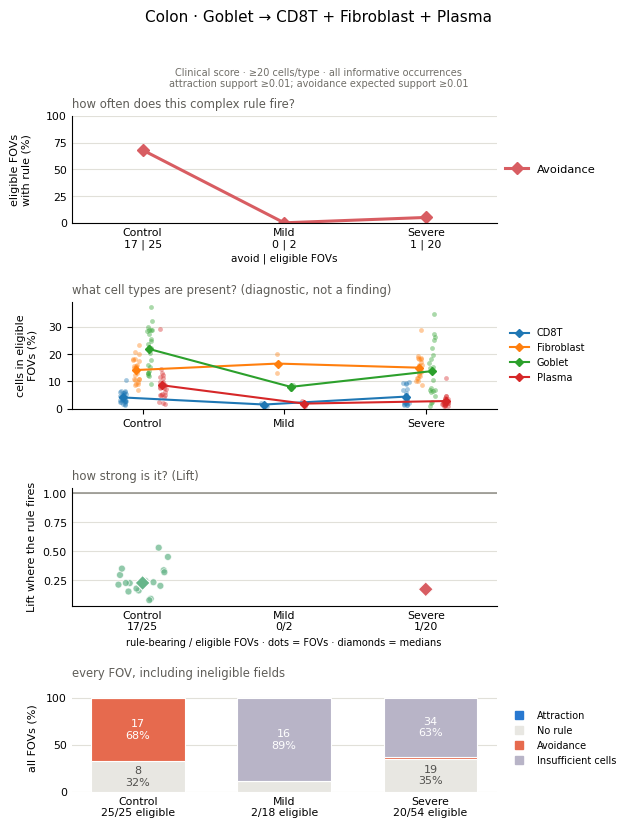

saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\staging_path_Colon_a78f846358_summary.pdf


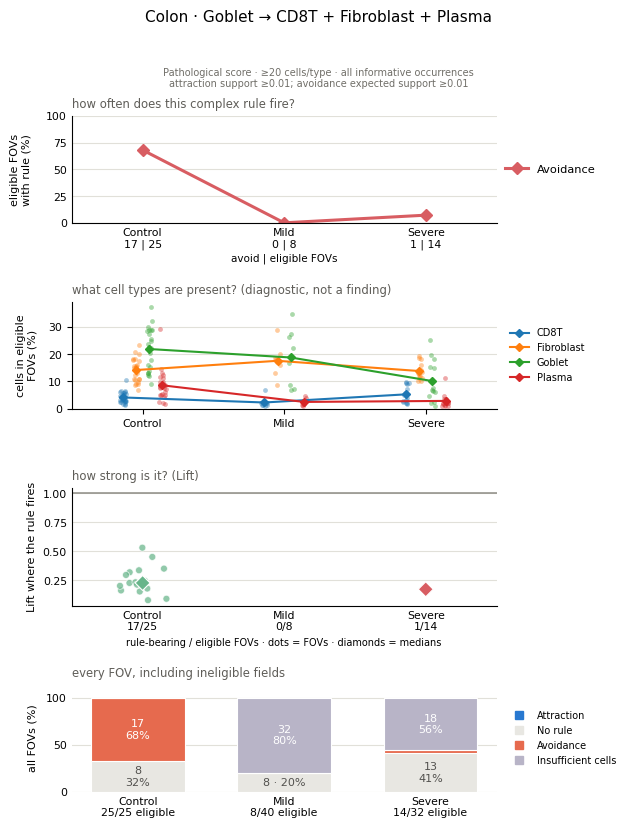

In [6]:
show_selected(0)

saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\staging_clin_Duodenum_7f53b8184b_summary.pdf


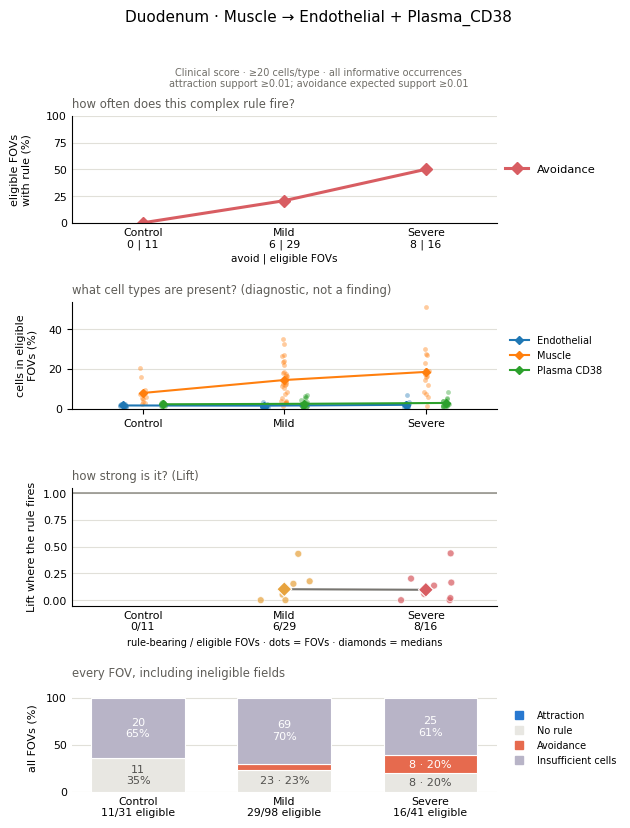

saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\staging_path_Duodenum_7f53b8184b_summary.pdf


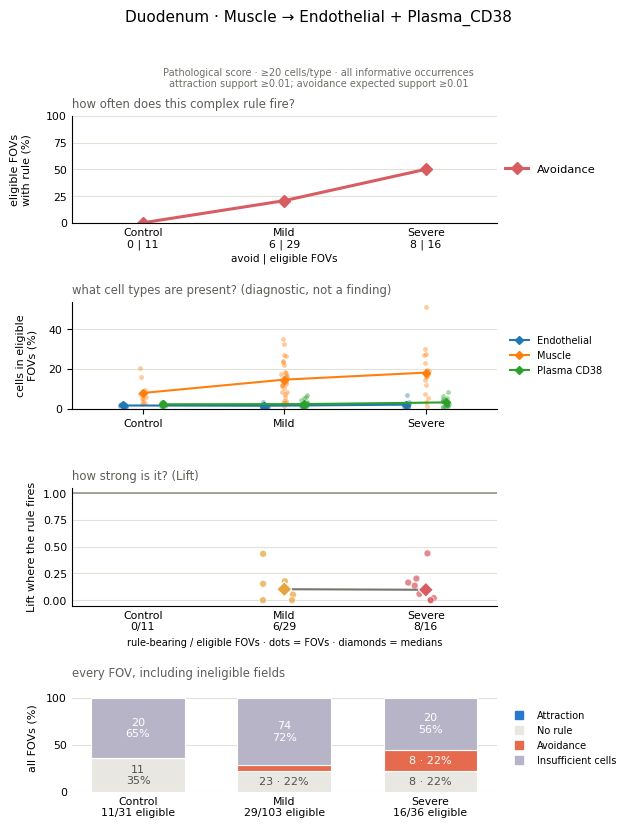

In [7]:
show_selected(1)

saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\staging_clin_Colon_25e4adecf2_summary.pdf


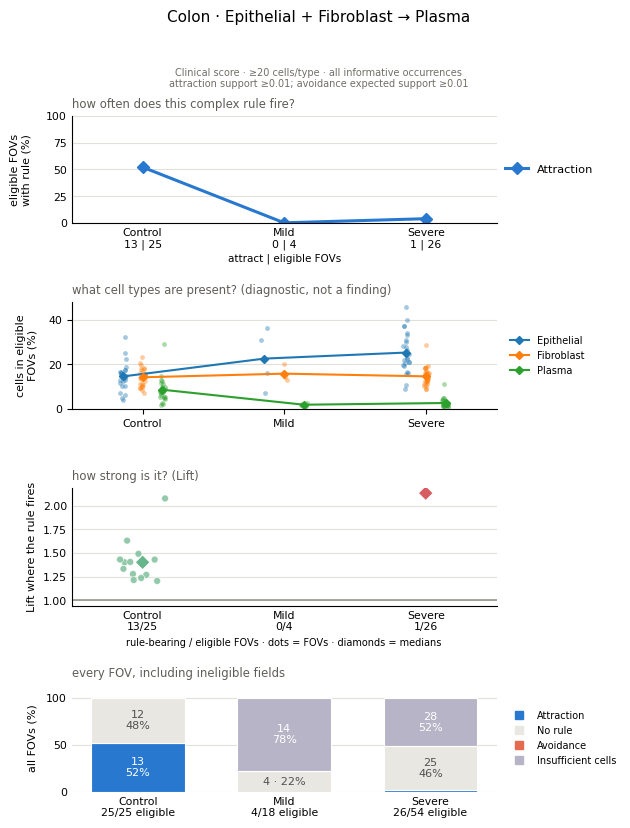

saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\staging_path_Colon_25e4adecf2_summary.pdf


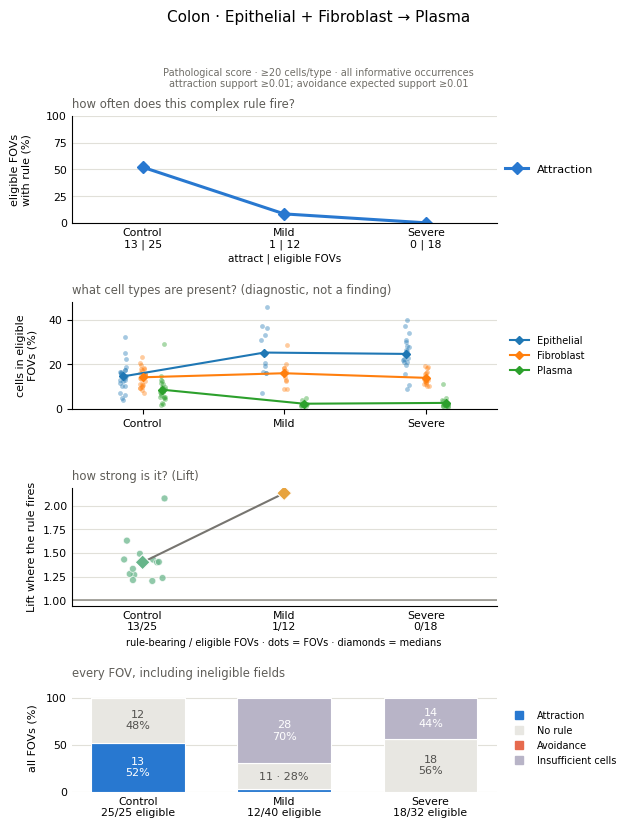

In [8]:
show_selected(2)

saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\staging_clin_Duodenum_ec81592ecb_summary.pdf


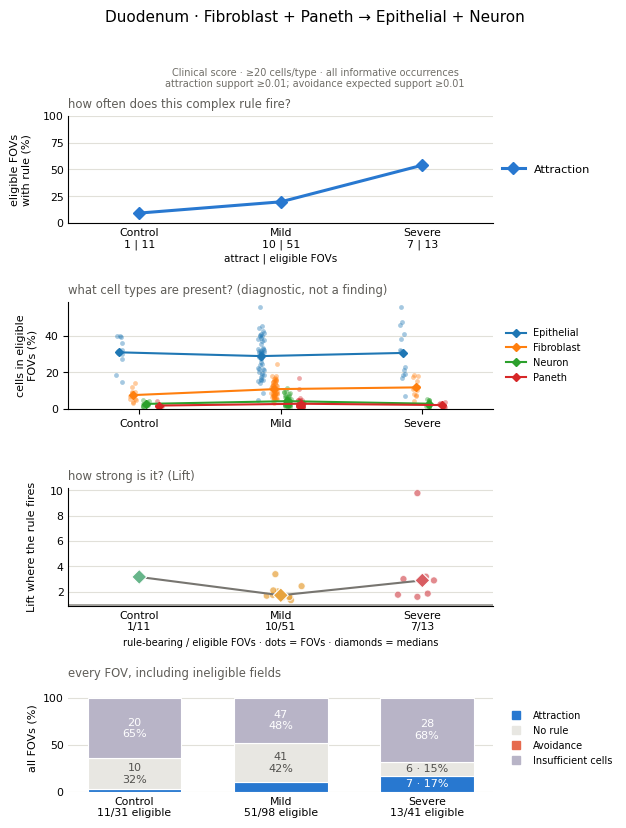

saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\staging_path_Duodenum_ec81592ecb_summary.pdf


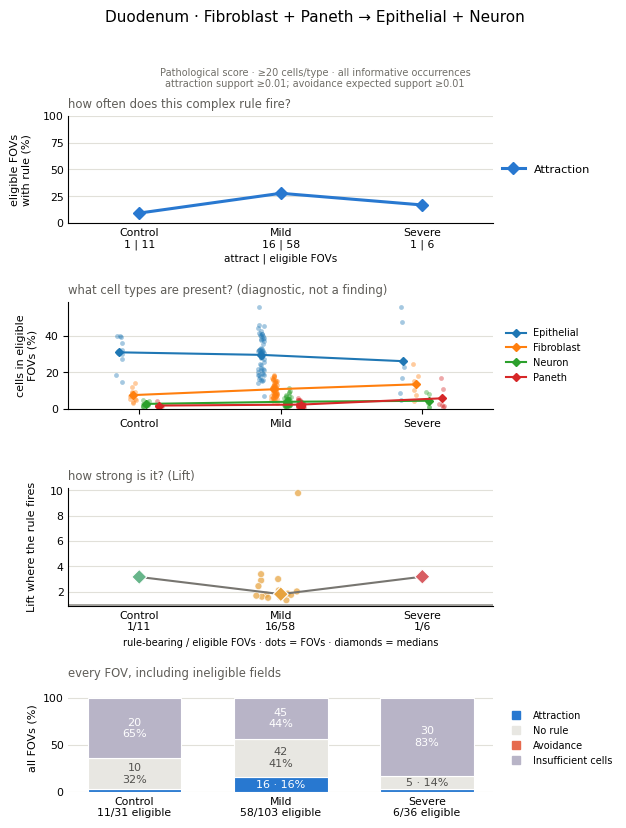

In [9]:
show_selected(3)